this file generate image colors

In [51]:
# import
import datetime
print(f"Notebook last run (end-to-end): {datetime.datetime.now()}")
from matplotlib.pylab import rand
import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}")
import matplotlib.pyplot as plt
import numpy as np
print(f"Numpy version: {np.__version__}")
from PIL import Image
import os
import random

Notebook last run (end-to-end): 2026-04-27 12:34:05.897884
TensorFlow version: 2.20.0
Numpy version: 2.1.3


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.9411008..4.655476].


Image shape: (100, 100, 3)


(np.float64(-0.5), np.float64(99.5), np.float64(99.5), np.float64(-0.5))

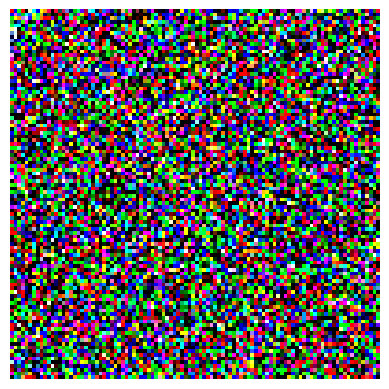

In [13]:
# code
# make a random color image of size 100 x 100
image = tf.random.normal([100, 100, 3])
print(f"Image shape: {image.shape}")
plt.imshow(image)
plt.axis('off')

(np.float64(-0.5), np.float64(99.5), np.float64(99.5), np.float64(-0.5))

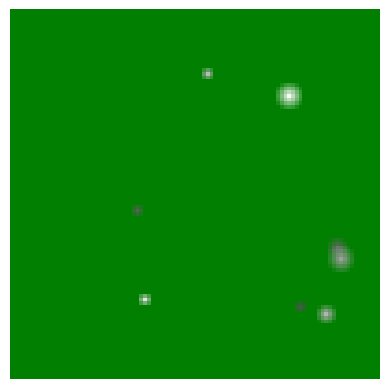

In [43]:
# 1. Create a solid green background
# RGB for Green is [0, 1, 0] or [0, 255, 0]
# We create a 100x100x3 tensor filled with [0, 0.5, 0] for a nice forest green
green_color = tf.constant([0.0, 0.5, 0.0])
image = tf.stack([tf.fill([100, 100], green_color[0]), tf.fill([100, 100], green_color[1]), tf.fill([100, 100], green_color[2])], axis=-1)

# Convert to a mutable numpy array so we can "draw" on it
image_np = image.numpy()

# 2. Add random circular white dots with radial fade
num_circles = random.randint(5, 15)  # Random number of circles between 5 and 15
for _ in range(num_circles):
    # Random center coordinates
    center_y = random.randint(0, 99)
    center_x = random.randint(0, 99)
    white_color = random.uniform(0.3, 1.0)  # Random brightness for the white dots
    
    # Random radius between 2 and 5 pixels
    radius = random.randint(2, 5)
    
    # Draw the circle with radial gradient fade
    for y in range(100):
        for x in range(100):
            # Euclidean distance formula: sqrt((x2-x1)^2 + (y2-y1)^2)
            dist = np.sqrt((x - center_x)**2 + (y - center_y)**2)
            if dist < radius:
                # Calculate fade factor: 1.0 at center, 0.0 at edge
                fade_factor = 1.0 - (dist / radius)
                
                # Get current pixel color
                current_color = image_np[y, x]
                
                # Blend white with current color based on fade factor
                new_color = current_color * (1 - fade_factor) + white_color * fade_factor
                image_np[y, x] = new_color

# 3. Display the result
plt.figure(frameon=False) # This removes the "frame" around the image
plt.imshow(image_np)
plt.axis('off') # This hides the "border" coordinates you mentioned earlier


In [53]:
def generate_image(save_path, filename):
    # 1. Create a solid green background
    green_color = tf.constant([0.0, random.uniform(0.4, 0.7), 0.0])
    image = tf.stack([tf.fill([100, 100], green_color[0]), 
                      tf.fill([100, 100], green_color[1]), 
                      tf.fill([100, 100], green_color[2])], axis=-1)
    
    # Convert to a mutable numpy array so we can "draw" on it
    image_np = image.numpy()
    
    # 2. Add random circular white dots with radial fade
    num_circles = random.randint(5, 45)  # Random number of circles between 5 and 45
    for _ in range(num_circles):
        # Random center coordinates
        center_y = random.randint(0, 99)
        center_x = random.randint(0, 99)
        white_color = random.uniform(0.3, 1.0)  # Random brightness for the white dots
        
        # Random radius between 2 and 5 pixels
        radius = random.randint(2, 5)
        
        # Draw the circle with radial gradient fade
        for y in range(100):
            for x in range(100):
                # Euclidean distance formula: sqrt((x2-x1)^2 + (y2-y1)^2)
                dist = np.sqrt((x - center_x)**2 + (y - center_y)**2)
                if dist < radius:
                    # Calculate fade factor: 1.0 at center, 0.0 at edge
                    fade_factor = 1.0 - (dist / radius)
                    
                    # Get current pixel color
                    current_color = image_np[y, x]
                    
                    # Blend white with current color based on fade factor
                    new_color = current_color * (1 - fade_factor) + white_color * fade_factor
                    image_np[y, x] = new_color
    
    # 3. Convert from float (0-1) to uint8 (0-255) and save
    image_uint8 = (image_np * 255).astype(np.uint8)
    img = Image.fromarray(image_uint8)
    
    # Create folder if it doesn't exist
    os.makedirs(save_path, exist_ok=True)
    
    # Save the image
    full_path = os.path.join(save_path, filename)
    img.save(full_path)
    print(f"Saved: {full_path}")

# Specify your folder path
output_folder = "data/"

# Generate and save 5 images
for i in range(5):
    generate_image(output_folder, f"image_{i+1}.png")

Saved: data/image_1.png
Saved: data/image_2.png
Saved: data/image_3.png
Saved: data/image_4.png
Saved: data/image_5.png
